In [1]:
from typing import Tuple

import numpy as np
import json


import time

import numpy as np

import  rigid
import tifffile
import matplotlib.pyplot as plt
import numpy as np
from caiman.mmapping import load_memmap
from pathlib import Path
from scipy.ndimage import gaussian_filter
from tifffile import TiffFile


In [2]:
# 1. load mmap
# 2. repalce z files with shifted z files
# 3. add the function into pipelne pipeline_mcorr_cnmf line 661
# 4. plot ther corrected z series

In [3]:

def compute_zpos(zstack_in, params_json, Treg_mmap_path):
    """Compute z position of frames given z-stack Zreg and Treg array.

    Parameters
    ----------
    Zreg_path : str
        Path to the z-stack TIFF file.
    params_json : str
        Path to the JSON file containing parameters.
    Treg_mmap_path : str
        Memory-mapped file path for the registered T-series.

    Returns
    -------
    zcorr : ndarray
        Array of shape (Zreg.shape[0], nFrames) containing the z-correlation values.
    """

    Zreg_path = zstack_in+"/zstack4_shifted.tif"
    # Load parameters from the JSON file
    with open(params_json, 'r') as file:
        params = json.load(file)

    # Get the zcorr parameters
    ops = params['zcorr']

    # Load the z-stack
    # zstack_tiff_file = tifffile.TiffFile(Zreg_path)
    # Zreg = zstack_tiff_file.asarray()
    # zstack_tiff_file.close()

    zstack_tiff_file = TiffFile(Zreg_path)
    Zreg = []
    for page in zstack_tiff_file.pages:
        Zreg.append(page.asarray())
    Zreg = np.stack(Zreg, axis=0)
    zstack_tiff_file.close()



    print(Zreg.shape, Zreg.dtype, Zreg.max(), Zreg.min())
    # Flip the Zreg
    Zreg = np.flip(Zreg, axis=1)

    # Load Treg_mmap_path
    mcorr_movie_16bit, dims, T = load_memmap(Treg_mmap_path)
    # Reshape the array to the desired dimensions
    Treg = np.reshape(mcorr_movie_16bit.T, [T] + list(dims), order='F')
    print(Treg.shape, Treg.dtype, Treg.max(), Treg.min())

    Ly, Lx = Treg.shape[1], Treg.shape[2]


    ops["nonrigid"] = False
    nplanes, zLy, zLx = Zreg.shape
    if Zreg.shape[1] > Ly or Zreg.shape[2] != Lx:
        Zreg = Zreg[:, :Ly, :Lx]

    nFrames, _, _ = Treg.shape
    zcorr = np.zeros((Zreg.shape[0], nFrames), np.float32)
    t0 = time.time()

    refAndMasks = []
    for Z in Zreg:
        if ops["1Preg"]:
            Z = Z.astype(np.float32)
            Z = Z[np.newaxis, :, :]
            if ops["pre_smooth"]:
                Z = utils.spatial_smooth(Z, int(ops["pre_smooth"]))
            Z = utils.spatial_high_pass(Z, int(ops["spatial_hp_reg"]))
            Z = Z.squeeze()

        maskMul, maskOffset = rigid.compute_masks(
            refImg=Z,
            maskSlope=3 * ops["smooth_sigma"],
        )
        cfRefImag = rigid.phasecorr_reference(refImg=Z, smooth_sigma=ops["smooth_sigma"])
        cfRefImag = cfRefImag[np.newaxis, :, :]
        refAndMasks.append((maskMul, maskOffset, cfRefImag))

    for nfr in range(nFrames):
        data = Treg[nfr:nfr + 1]  # Get the current frame
        inds = np.array([nfr])     # Index of the current frame

        for z, ref in enumerate(refAndMasks):
            if ops["1Preg"]:
                data = data.astype(np.float32)
                if ops["pre_smooth"]:
                    data = utils.spatial_smooth(data, int(ops["pre_smooth"]))
                data = utils.spatial_high_pass(data, int(ops["spatial_hp_reg"]))

            maskMul, maskOffset, cfRefImg = ref
            cfRefImg = cfRefImg.squeeze()

            _, _, zcorr[z, inds] = rigid.phasecorr(
                data=rigid.apply_masks(data=data, maskMul=maskMul, maskOffset=maskOffset),
                cfRefImg=cfRefImg,
                maxregshift=ops["maxregshift"],
                smooth_sigma_time=ops["smooth_sigma_time"],
            )

        if nfr % 10 == 0:
            print(f"{z + 1} planes, {nfr + 1}/{nFrames} frames, {time.time() - t0:.2f} sec.")

    print(f"{z + 1} planes, {nFrames}/{nFrames} frames, {time.time() - t0:.2f} sec.")


    # Apply Gaussian smoothing along the Z dimension
    zcorr = gaussian_filter(zcorr, sigma=[1, 0])  # Adjust sigma[0] for the desired smoothing level

    return zcorr

In [4]:
# ops = {         
    
#     'smooth_sigma': 1.15,         # Standard deviation for Gaussian smoothing of Z-stack
#     '1Preg': False,              # False for two-photon data
#     'pre_smooth': 0,             # Pre-smoothing is not typically used for 2P data
#     'spatial_hp_reg': 42,         # High-pass filtering is not typically used for 2P data
#     'spatial_taper': 40,         # Width of the taper applied to the edges of the frames
#     'maxregshift': 0.1,           # Maximum allowed shift in pixels during registration
#     'smooth_sigma_time': 0,      # Standard deviation for temporal smoothing of registration shifts
#     'nonrigid': False,           # False for rigid registration
# }

# Zreg_path=  "D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01042024/ZSeries-01042024-1531-001/zstack4_shifted.tif"
Zreg_path = "D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/zstack4_shifted1.tif"

proc_folder = Path('D:/Analysis_2P/Data/Analysis/C57_O1M2/10022023/run2/mesmerize')
mcorr_folder = '19fa5a4a-0d1d-4063-b67d-eee4a56e8a14'
mcorr_mmap = f"{mcorr_folder}-cat_tiff_bt_els__d1_765_d2_765_d3_1_order_F_frames_1600.mmap"
Treg_mmap_path = proc_folder / mcorr_folder / mcorr_mmap
params_json = "D:/Analysis_2P/Analysis_2P/Mesmerize/parameters/params_zshift_default.json"


In [5]:
zcorr = compute_zpos(Zreg_path,params_json,Treg_mmap_path) 

(41, 765, 765) uint8 255 0
(1600, 765, 765) float32 65535.0 0.0
41 planes, 1/1600 frames, 5.34 sec.
41 planes, 11/1600 frames, 17.53 sec.
41 planes, 21/1600 frames, 29.77 sec.
41 planes, 31/1600 frames, 42.17 sec.
41 planes, 41/1600 frames, 54.53 sec.
41 planes, 51/1600 frames, 67.04 sec.
41 planes, 61/1600 frames, 79.31 sec.
41 planes, 71/1600 frames, 91.45 sec.
41 planes, 81/1600 frames, 103.72 sec.
41 planes, 91/1600 frames, 115.92 sec.
41 planes, 101/1600 frames, 128.07 sec.
41 planes, 111/1600 frames, 140.31 sec.
41 planes, 121/1600 frames, 152.44 sec.
41 planes, 131/1600 frames, 164.73 sec.
41 planes, 141/1600 frames, 176.89 sec.
41 planes, 151/1600 frames, 189.07 sec.
41 planes, 161/1600 frames, 201.19 sec.
41 planes, 171/1600 frames, 213.27 sec.
41 planes, 181/1600 frames, 225.46 sec.
41 planes, 191/1600 frames, 237.71 sec.
41 planes, 201/1600 frames, 250.26 sec.
41 planes, 211/1600 frames, 262.61 sec.
41 planes, 221/1600 frames, 274.63 sec.
41 planes, 231/1600 frames, 286.98 s

In [6]:
zcorr.shape

(41, 1600)

In [7]:
zcorr

array([[0.00132533, 0.00123291, 0.0011839 , ..., 0.00126152, 0.00127274,
        0.00112899],
       [0.00128991, 0.00131233, 0.00121984, ..., 0.00122772, 0.00134907,
        0.00116621],
       [0.00123006, 0.00137553, 0.00122929, ..., 0.00121492, 0.00134413,
        0.00122931],
       ...,
       [0.00118779, 0.00125865, 0.00138985, ..., 0.00127969, 0.00123884,
        0.00126509],
       [0.00121816, 0.00130867, 0.0013368 , ..., 0.00128817, 0.00122943,
        0.0012247 ],
       [0.00125266, 0.00135612, 0.001275  , ..., 0.00130949, 0.00127047,
        0.00118896]], dtype=float32)

In [8]:

# Apply Gaussian smoothing along the Z dimension
# smoothed_zcorr = gaussian_filter(zcorr, sigma=[0,1])  # Adjust sigma[0] for the desired smoothing level


In [9]:
z_positions = np.argmax(zcorr, axis=0)
print(z_positions)

[ 6  5 20 ... 16 33 13]


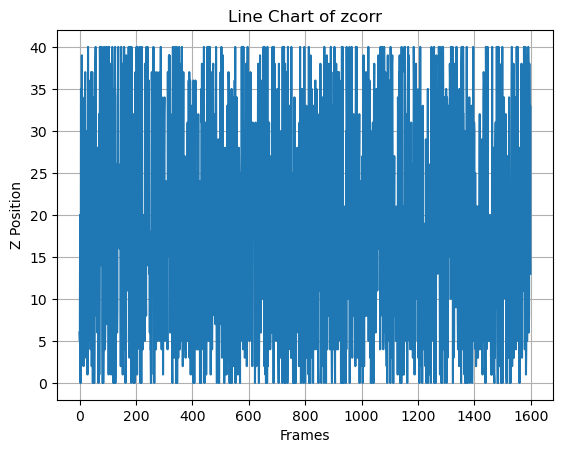

In [10]:
import matplotlib.pyplot as plt

def plot_zcorr(zcorr):
    plt.plot(zcorr)
    plt.xlabel('Frames')
    plt.ylabel('Z Position')
    plt.title('Line Chart of zcorr')
    plt.grid(True)
    plt.show()

# Example usage
plot_zcorr(z_positions)

In [11]:
zcorr

array([[0.00132533, 0.00123291, 0.0011839 , ..., 0.00126152, 0.00127274,
        0.00112899],
       [0.00128991, 0.00131233, 0.00121984, ..., 0.00122772, 0.00134907,
        0.00116621],
       [0.00123006, 0.00137553, 0.00122929, ..., 0.00121492, 0.00134413,
        0.00122931],
       ...,
       [0.00118779, 0.00125865, 0.00138985, ..., 0.00127969, 0.00123884,
        0.00126509],
       [0.00121816, 0.00130867, 0.0013368 , ..., 0.00128817, 0.00122943,
        0.0012247 ],
       [0.00125266, 0.00135612, 0.001275  , ..., 0.00130949, 0.00127047,
        0.00118896]], dtype=float32)

In [12]:
# compare suite2p data
import numpy as np
from scipy.io import loadmat

def load_mat_to_ndarray(file_path, variable_name):
    """
    Load a specified variable from a .mat file and convert it to a NumPy ndarray.
    
    Parameters:
    - file_path: str, the path to the .mat file.
    - variable_name: str, the name of the variable in the .mat file to convert to an ndarray.
    
    Returns:
    - ndarray: The specified variable as a NumPy ndarray.
    """
    # Load the .mat file
    data = loadmat(file_path)
    
    # Extract the specified variable
    if variable_name in data:
        ndarray = data[variable_name]
        # Check if the loaded data is structured or requires further processing
        if isinstance(ndarray, np.ndarray):
            return ndarray
        else:
            raise ValueError(f"{variable_name} is not stored as an ndarray.")
    else:
        raise KeyError(f"{variable_name} not found in the .mat file.")




In [13]:
# Usage example

file_path = "C:/Users/Kyle/Downloads/zcorr (1).mat"
ndarray = load_mat_to_ndarray(file_path,"zcorr")
print(ndarray)

[[0.02578953 0.0245498  0.02505897 ... 0.02274074 0.02202147 0.02125841]
 [0.02708661 0.02590596 0.02631152 ... 0.02416165 0.02341573 0.02267386]
 [0.03011942 0.02919449 0.02946685 ... 0.02681102 0.02643238 0.02537469]
 ...
 [0.00700971 0.00721084 0.00712228 ... 0.00741906 0.00758592 0.00754977]
 [0.00668002 0.00693061 0.00678504 ... 0.00713364 0.00684139 0.00703289]
 [0.00625208 0.00620411 0.00682357 ... 0.00697092 0.00674299 0.00679187]]


In [14]:
ndarray.shape

(41, 1600)

In [15]:
z_positions_suite2p = np.argmax(ndarray, axis=0)
print(z_positions_suite2p)

[ 9  9  9 ... 12 13 12]


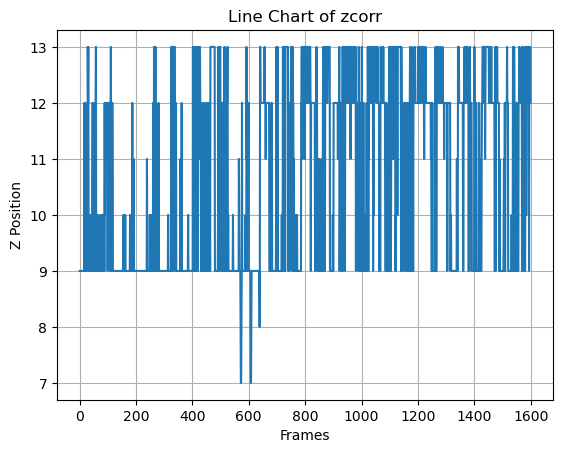

In [16]:
# Example usage
plot_zcorr(z_positions_suite2p)

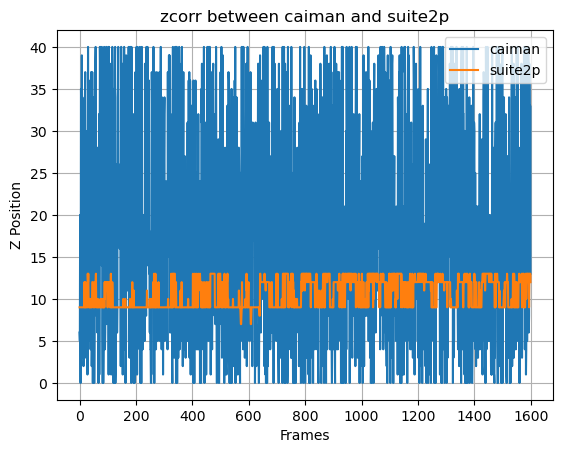

In [17]:
# plot two figures together
plt.plot(z_positions, label='caiman')
plt.plot(z_positions_suite2p, label='suite2p')
plt.xlabel('Frames') 
plt.ylabel('Z Position')
plt.title('zcorr between caiman and suite2p')
plt.legend()
plt.grid(True)
plt.show()


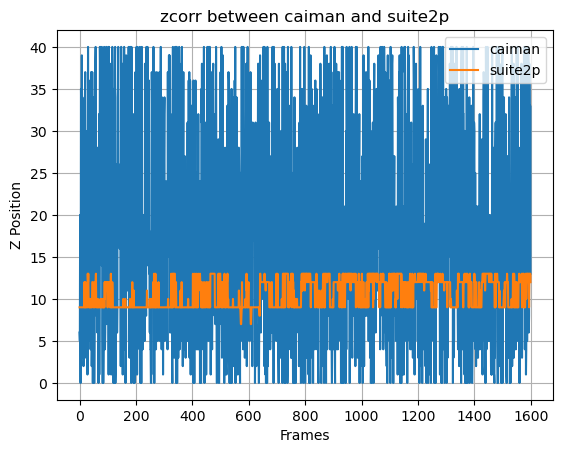

In [18]:
# plot two figures together
plt.plot(z_positions, label='caiman')
plt.plot(z_positions_suite2p, label='suite2p')
plt.xlabel('Frames') 
plt.ylabel('Z Position')
plt.title('zcorr between caiman and suite2p')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# load mat file
import numpy as np
from scipy.io import loadmat
# LOAD 

In [20]:

# 找出不同值的索引
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]
print("z_positions_caiman: ", z_positions)
print("z_positions_suite2p: ", z_positions_suite2p)
print("Index of difference frames: ", different_indices)
print(len(different_indices))

z_positions_caiman:  [ 6  5 20 ... 16 33 13]
z_positions_suite2p:  [ 9  9  9 ... 12 13 12]
Index of difference frames:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,

In [21]:
import scipy.io

# Assuming z_positions and z_positions_suite2p are defined
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]

# Create a dictionary to store the data
mat_data = {
    'z_positions_caiman': z_positions,
    'z_positions_suite2p': z_positions_suite2p,
    'index_of_difference_frames': different_indices
}


# Save the dictionary to a .mat file
scipy.io.savemat('difference_indices_10022023_1300_002.mat', mat_data)

print("Results have been saved to difference_indices.mat")





Results have been saved to difference_indices.mat


In [22]:
# load it back
import scipy.io
import numpy as np
mat_data = scipy.io.loadmat('difference_indices_10022023_1300_002.mat')
z_positions_caiman = mat_data['z_positions_caiman']
z_positions_suite2p = mat_data['z_positions_suite2p']

# compute the error rate between two z positions
error_rate = np.mean(z_positions_caiman != z_positions_suite2p)
print("error_rate",error_rate)

# compute the rate that the difference is within 1 frame
within_1_frame_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 1)
print("diff_exceed_1_frame_rate",within_1_frame_rate)


# compute the rate that the difference is within 2 frames
within_2_frames_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 2)
print("diff_exceed__2_frame_rate",within_2_frames_rate)



# compute the rate that the difference is within 3 frames
within_3_frames_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 3)
print("diff_exceed__3_frame_rate",within_3_frames_rate)


error_rate 0.99125
diff_exceed_1_frame_rate 0.96125
diff_exceed__2_frame_rate 0.92625
diff_exceed__3_frame_rate 0.875
